# Stochastic model
assuming a 1000-block pasture

In [274]:
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

from math import exp
from math import factorial as fac

In [282]:
R = 0.00888
K = 0.00772
Dt = 0.05

In [283]:
def skellamPMF(N, Ng):
    """returns a vector containing the pmf for delta N_g given the initial value of N_g
    and the sheep population

    vector contains 11 elements, the pmf for delta N_g from -5 to +5
    """

    #if N_g = 1000, the skellam distribution reduces to a poisson with mean NRNg/A Dt
    #if N_g = 0, delta Ng = 0 with 100% certainty
    #sp.stats.skellam.pmf() does not work with either of the means equal to 0
    if Ng == 1000:
        ret = sp.stats.poisson.pmf(-np.arange(-5, 6), N*R*Ng/A*Dt)
    elif Ng == 0:
        ret = np.zeros(11)
        ret[5]=1
    else:
        ret =  sp.stats.skellam.pmf(np.arange(-5, 6), K*Ng*(1-Ng/A)*Dt, N*R*Ng/A*Dt)

    #normalize - we are cutting off the distribution at +-5 so we need sum to be 1
    return ret/np.sum(ret)

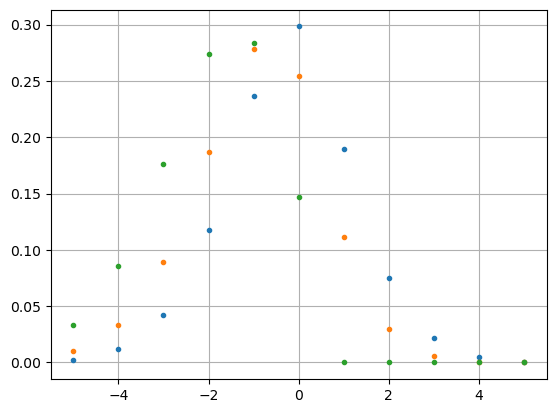

In [284]:
f, ax = plt.subplots()

ax.plot(np.arange(-5, 6), skellamPMF(435, 600), ".")
ax.plot(np.arange(-5, 6), skellamPMF(435, 800), ".")
ax.plot(np.arange(-5, 6), skellamPMF(435, 1000), ".")

ax.grid(True)

plt.show()

## Stochastic model using iterative skellam convolution

In [285]:
def step(N, Ng):
    """takes in the distribution of Ng at time t_0
    and returns the distribution of Ng at time t_0 + Delta t
    """

    Ng_t0Dt = np.zeros(1001)
    for i in range(0, Ng.size):
        #insert skellam pmf into 1001-element array such that element j is the probability of
        #landing at Ng=j given you started at Ng=i
        skellam_entire = np.zeros(1001)
        skellam = skellamPMF(N, i)
        for j in range(0, 11):
            if not(i+j-5 > 1000 or i+j-5 < 0):
                skellam_entire[i+j-5]=skellam[j]
        #add on to results
        Ng_t0Dt += skellam_entire*Ng[i]

    return Ng_t0Dt

In [ ]:
Ng0 = np.zeros(1001)
Ng0[1000] = 1

b = Ng0

ng_result=np.array(Ng0, ndmin=2)

for i in range(0, 10000):
    b = step(435, b)
    ng_result = np.append(ng_result, np.array(b, ndmin=2), 0)
    if i%10 == 0:
        print("finished iteration {0}".format(i))

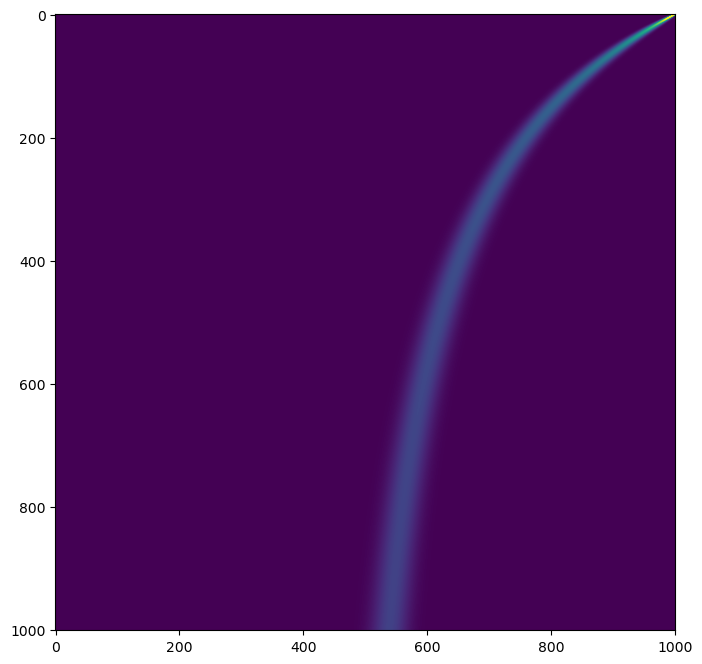

In [289]:
f, ax = plt.subplots(figsize=(8,8))
ax.imshow(ng_result, vmin=0, vmax=0.1, aspect="auto")
plt.show()